In [453]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import itertools
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(42)

dtype = torch.float32
complex_dtype = torch.complex64 if dtype == torch.float32 else torch.complex128

# go-mHC Class
class GeneralizedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, orthonormal=True, init=torch.rand):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.total_dim = d * s
        
        # Add a batch dimension: (batch_size, ds, ds)
        self.raw_u = nn.Parameter(init(
            self.batch_size, self.total_dim, self.total_dim, 
            dtype=dtype if orthonormal else complex_dtype
        ))
        
        # self.softmax = nn.Softmax(dim=-1)

    def get_unitary(self):
        # Batch-wise adjoint and matrix exponential
        ru = self.raw_u
        # ru = self.softmax(self.raw_u)
        
        X = ru - ru.adjoint() 
        # Can instead do matrix exp, but that is worse for many reasons (stability, number of operations, etc.)
        # return torch.matrix_exp(X)
        
        # Cayley Transform
        I = torch.eye(self.total_dim, device=X.device).unsqueeze(0).expand(self.batch_size, -1, -1)
        U = torch.linalg.solve(I - X, I + X)
        return U

    def forward(self):
        U = self.get_unitary()
        
        # Reshape to (batch, d, s, d, s) -> (batch, d, d, s, s)
        blocks = U.view(self.batch_size, self.d, self.s, self.d, self.s).permute(0, 1, 3, 2, 4)
        
        # Sum across the internal s x s blocks for the whole batch
        bistochastic_matrices = torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / self.s
        
        return bistochastic_matrices

class AveragedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, free_s=False):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.free_s = free_s
    
        self.raw_u = nn.Parameter(torch.rand(
            self.batch_size, self.s, self.d, self.d, 
            dtype=dtype
        ))
        
        # if self.s >= 2:
        #     with torch.no_grad():
        #         # set second matrix init to something that makes identity
        #         self.raw_u[:, 1, :, :] = 10*torch.rand(
        #             self.batch_size, self.d, self.d, 
        #             dtype=torch.float32
        #         )

        if free_s:
            self.s_param = nn.Parameter(torch.rand(self.s, dtype=dtype))
        
    def get_unitary(self):
        # Batch-wise adjoint and cayley transform using solve
        X = self.raw_u - self.raw_u.transpose(-2, -1)
        I = torch.eye(self.d, dtype=X.dtype, device=X.device).expand_as(X)
        return torch.linalg.solve(I - 0.5 * X, I + 0.5 * X)
    
    def forward(self):
        U = self.get_unitary()
        
        if self.free_s:
            # map learned s_param to values between 0 and 1 that sum to 1 using sigmoid and normalization
            sigmoid_s = torch.sigmoid(self.s_param)
            prefactors = sigmoid_s / sigmoid_s.sum()
        # else:
        #     prefactors = 1.0 / self.s
        
        # take squared of U
        u_squared = torch.abs(U) ** 2
        
        # average over s
        if self.free_s:
            # print("shapes", u_squared.shape, prefactors.shape)
            s_avg = torch.einsum('bsot, s -> bot', u_squared, prefactors)
        else:
            s_avg = u_squared.sum(dim=1) / self.s
        
        return s_avg
    
    
# get all nxn permutation matrices as a tensor of shape (n!, n, n)
def get_permutation_matrices(n):
    perms = list(itertools.permutations(range(n)))
    matrices = [torch.zeros(n, n, dtype=dtype).index_put_((torch.arange(n), torch.tensor(p)), torch.tensor(1.0, dtype=dtype)) for p in perms]
    return torch.stack(matrices)

# Sinkhorn normalization to make a matrix doubly stochastic (same as in mHC paper)
# Repeatedly normalize rows and columns until convergence (or max iterations)
def sinkhorn(M, num_iters=20):
    # check if M is already doubly stochastic
    if torch.allclose(M.sum(dim=-1), torch.ones(M.shape[0], M.shape[1]), atol=1e-8) and torch.allclose(M.sum(dim=-2), torch.ones(M.shape[0], M.shape[2]), atol=1e-8):
        return M
    # Works on [B, n, n]
    for _ in range(num_iters):
        M = abs(M)  # Ensure non-negativity
        M = M / M.sum(dim=-1, keepdim=True)  # Row
        M = M / M.sum(dim=-2, keepdim=True)  # Col
    return M

# Class that implements both mHC-lite and KromHC
# To do KromHC, you have multiple num_factors and N=2 (num_factors is log2 of the dimension of the matrix)
# To do mHC-lite, you have num_factors=1 and N=n (the dimension of the matrix)
class GeneralizedKromHC(nn.Module):
    def __init__(self, num_factors, N=3, batch_size=1):
        super().__init__()
        self.num_factors = num_factors
        self.N = N
        self.batch_size = batch_size
        
        # Precompute all N! permutation matrices
        perms = list(itertools.permutations(range(N)))
        self.num_perms = len(perms)
        
        perm_mats = torch.zeros((self.num_perms, N, N), dtype=dtype)
        for i, p in enumerate(perms):
            for row, col in enumerate(p):
                perm_mats[i, row, col] = 1.0
        self.register_buffer('perm_mats', perm_mats)

        # Logits for the convex combination
        self.coeffs = nn.Parameter(torch.randn(batch_size, num_factors, self.num_perms))

    def forward(self):
        weights = F.softmax(self.coeffs, dim=-1) 
        
        # Build factor matrices: (Batch, Num_Factors, N, N)
        factor_mats = (weights.view(self.batch_size, self.num_factors, self.num_perms, 1, 1) * self.perm_mats.view(1, 1, self.num_perms, self.N, self.N)).sum(dim=2)
        
        res = factor_mats[:, 0, :, :]
        
        for k in range(1, self.num_factors):
            mat = factor_mats[:, k, :, :]
            curr_dim = res.shape[1]
            
            res_expanded = res.view(self.batch_size, curr_dim, 1, curr_dim, 1)
            mat_expanded = mat.view(self.batch_size, 1, self.N, 1, self.N)
            
            res = (res_expanded * mat_expanded).reshape(
                self.batch_size, curr_dim * self.N, curr_dim * self.N
            )
        return res

# Target Generation Code

In [454]:
import torch

def generate_haar_unitary_batch(d, batch_size=1, device='cpu', dtype=complex_dtype):
    """
    Generates a batch of d x d Haar random unitaries.
    Output shape: (batch_size, d, d)
    """
    if d > 1000 and batch_size < 25:
        raise ValueError("Did you swap d and batch_size?")
    # 1. Generate batch of random complex matrices
    # Using complex128 for higher numerical precision in testing
    z = torch.randn(batch_size, d, d, dtype=dtype, device=device)
    
    # 2. Batch QR decomposition
    q, r = torch.linalg.qr(z)
    
    # 3. Extract diagonals for the whole batch
    # diag_r shape: (batch_size, d)
    diag_r = torch.diagonal(r, dim1=-2, dim2=-1)
    
    # 4. Compute phases and reshape for broadcasting
    # phases shape: (batch_size, 1, d) to multiply against columns of Q
    phases = (diag_r / torch.abs(diag_r)).unsqueeze(-2)
    
    # 5. Apply phase correction
    u = q * phases
    
    return u

import torch

def generate_haar_orthogonal_batch(d, batch_size, device='cpu', dtype=dtype):
    """
    Generates a batch of d x d Haar-random orthogonal matrices.
    Output shape: (batch_size, d, d)
    """
    assert d < 100
    
    # 1. Generate real Gaussian random matrix
    a = torch.randn(batch_size, d, d, dtype=dtype, device=device)
    
    # 2. QR decomposition
    q, r = torch.linalg.qr(a)
    
    # 3. Extract diagonal of R and compute signs
    diag_r = torch.diagonal(r, dim1=-2, dim2=-1)
    # torch.sign returns -1, 0, or 1. Gaussian entries are almost never 0.
    signs = torch.sign(diag_r).unsqueeze(-2)
    
    # 4. Apply sign correction to Q
    ortho_batch = q * signs
    
    return ortho_batch

def generate_uniform_params(n, batch_size=1):
  """
  Generates n random parameters that sum to 1, uniformly distributed.

  Args:
    n: The number of parameters to generate.
    batch_size: The number of sets of parameters to generate.
  Returns:
    A numpy array of shape (batch_size, n) where each row sums to 1.
  """
  # Alpha parameter: use 1.0 for a uniform distribution over the simplex
  alpha = np.ones(n)
  # Draw samples
  params = np.random.dirichlet(alpha, size=batch_size)
  return torch.Tensor(params)

In [455]:
import math

def generate_birkhoff_using_SK(d, batch_size=1, device='cpu'):
    return sinkhorn(torch.rand(batch_size, d, d, device=device))

def generate_birkhoff_using_haar_unitary(s):
    def _generate_birkhoff_using_haar_unitary(d, batch_size=1, device='cpu', return_generator=False):
        """
        Generates a batch of d x d bistochastic matrices using the go-mHC construction with Haar random unitaries.
        """
        U = generate_haar_unitary_batch(d * s, batch_size, device=device)
        
        blocks = U.view(batch_size, d, s, d, s).permute(0, 1, 3, 2, 4)
            
        # Sum across the internal s x s blocks for the whole batch
        if return_generator:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s, U
        else:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s
    
    _generate_birkhoff_using_haar_unitary.__name__ = f"generate_birkhoff_using_haar_unitary(s={s})"
    return _generate_birkhoff_using_haar_unitary

def generate_birkhoff_using_haar_orthogonal(s):
    def _generate_birkhoff_using_haar_orthogonal(d, batch_size=1, device='cpu', return_generator=False):
        """
        Generates a batch of d x d bistochastic matrices using the go-mHC construction with Haar random orthogonal matrices.
        """
        U = generate_haar_orthogonal_batch(d * s, batch_size, device=device)
        
        blocks = U.view(batch_size, d, s, d, s).permute(0, 1, 3, 2, 4)
            
        # Sum across the internal s x s blocks for the whole batch
        if return_generator:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s, U
        else:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s
    _generate_birkhoff_using_haar_orthogonal.__name__ = f"generate_birkhoff_using_haar_orthogonal(s={s})"
    return _generate_birkhoff_using_haar_orthogonal

def generate_birkhoff_using_BN_theorem(d, batch_size=1, device='cpu', safe=True):
    if d > 7 and safe:
        raise ValueError("d! is too large, use safe=False to bypass.")
    
    num_permutations = math.factorial(d)
    prefactors = generate_uniform_params(num_permutations, batch_size=batch_size)
    
    # Get permutation matrices on the correct device and dtype
    perm_mats = get_permutation_matrices(d).to(device=device, dtype=dtype)
    
    # Build target matrices using einsum as a weighted sum of permutation matrices
    target_mats = torch.einsum('bp, pjk -> bjk', prefactors, perm_mats)
    
    return target_mats

def generate_random_eigval_targets_unit_circle(d, batch_size=1, device='cpu'):
    # Generate random eigenvalues on the unit circle
    angles = torch.rand(batch_size, device=device, dtype=dtype) * 2 * math.pi
    mags = torch.rand(batch_size, device=device, dtype=dtype) ** 0.5
    eigvals = mags * torch.exp(1j * angles)
    return eigvals

def generate_random_eigval_targets_complex_square(d, batch_size=1, device='cpu'):
    real = torch.rand(batch_size, device=device, dtype=dtype) * 2 - 1
    imag = torch.rand(batch_size, device=device, dtype=dtype) * 2 - 1
    return real + 1j * imag

def generate_grid_eigval_targets_complex_square(d, batch_size=1, device='cpu'):
    # Generate a grid of eigenvalues in the complex plane
    num_points_per_axis = int(batch_size ** 0.5)
    second_axis_points = int(batch_size / num_points_per_axis)
    real_parts = torch.linspace(-1, 1, num_points_per_axis, device=device, dtype=dtype)
    imag_parts = torch.linspace(-1, 1, second_axis_points, device=device, dtype=dtype)
    grid_real, grid_imag = torch.meshgrid(real_parts, imag_parts)
    eigvals = grid_real.flatten() + 1j * grid_imag.flatten()
    return eigvals[:batch_size]  # Return only the requested number of eigenvalues

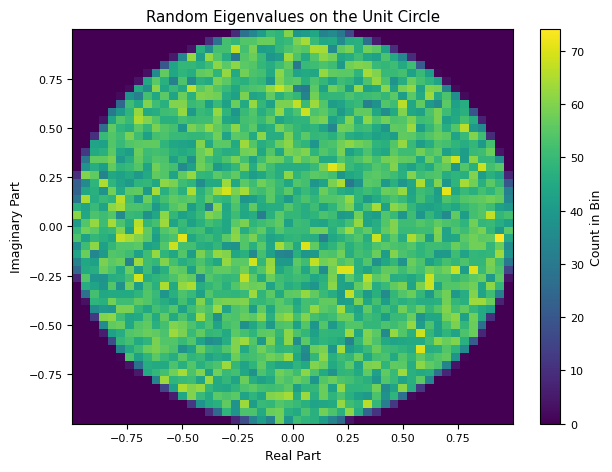

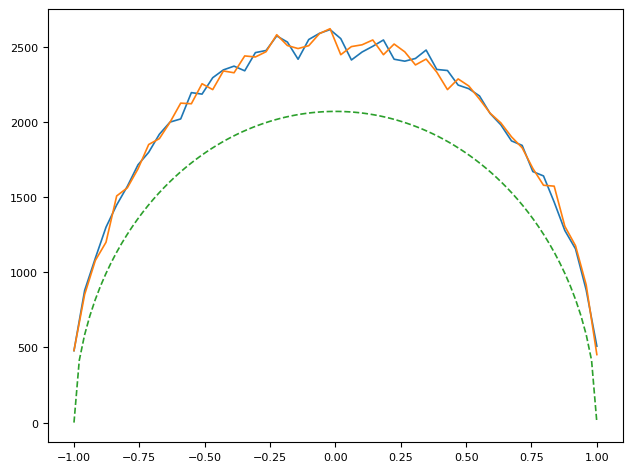

In [456]:
eigtest = generate_random_eigval_targets_unit_circle(4, batch_size=100_000)

# heatmap of real vs imag parts
h = plt.hist2d(eigtest.real.cpu().numpy(), eigtest.imag.cpu().numpy(), bins=50, cmap='viridis')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Random Eigenvalues on the Unit Circle')
plt.colorbar(label='Count in Bin')

plt.figure()
# plt.hist(h[0].flatten(), bins=50)
x = np.linspace(-1, 1, 100)
plt.plot(np.linspace(-1, 1, len(h[0].sum(axis=0))), h[0].sum(axis=0))  # sum over rows to get distribution of real parts
plt.plot(np.linspace(-1, 1, len(h[0].sum(axis=0))), h[0].sum(axis=1))
# area of a circle per unit length is 2*sqrt(1-x^2), where x is the real part, so plot that for comparison

plt.plot(x, 2 * 6500 * np.sqrt(1 - x**2) / (2 * np.pi), label='Expected Distribution', linestyle='dashed')

# Toy Models

In [490]:
class DatasetModel():
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.targets = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
        X = torch.rand(self.batch_size, self.dataset_size, self.d, device=self.device, dtype=dtype)
        sparse_mask = (torch.rand_like(X) > self.sparsity).to(dtype)
        X = X * sparse_mask.sum(dim=-1, keepdim=True)
        Y = torch.einsum('bij,bdj->bdi', self.targets, X) + (self.noise_mag * torch.rand(self.batch_size, self.dataset_size, self.d, device=self.device, dtype=dtype))
        
        self.X = X
        self.Y = Y
    
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        return self.Y, tildeY
    
    
class TargetMatrixModel():
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.targets = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        noise = self.noise_mag * torch.rand_like(self.targets, dtype=dtype, device=self.device)
        return self.targets + noise, output
    
class DatasetModelWithStaticHpre(DatasetModel):
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "num"
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.Hpre_layer_target = torch.rand(self.batch_size, self.d, device=self.device, dtype=dtype)  # Target for the pre_layer to learn        
        self.Y = torch.einsum('bj,bkj->bk', self.Hpre_layer_target, self.Y)  # Apply the same pre_layer transformation to targets
        
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        tildeY = torch.einsum('bi,bdi->bd', self.Hpre_layer_target, tildeY)  # Apply the same pre_layer transformation to the output
        return self.Y, tildeY

class DatasetModelWithLearnedHpre(DatasetModelWithStaticHpre):
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "num"
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # pre_layer_init = torch.ones(self.d, device=self.device) + 0.1*torch.randn(self.d, device=self.device)  # Initialize around the identity transformation
        self.H_pre = nn.Parameter(self.Hpre_layer_target.clone() + 0.1*torch.randn(self.d, device=self.device), requires_grad=True)
    
    def parameters(self):
        # return [self.model.parameters(), self.H_pre]
        yield from self.model.parameters()
        yield self.H_pre
    
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        tildeY = torch.einsum('bi,bdi->bd', self.H_pre, tildeY)  # Apply the learned pre_layer transformation to the output
        return self.Y, tildeY
    
# given an eigenvalue target array, have Y be the eigval of interest and tildeY be the closest eigenvalue of the output to that target
class TargetEigenvalueModel():
    Y_Ytilde_type = "complex"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.target_eigvals = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=targets.dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        # Get eigenvalues of the output
        eigvals = torch.linalg.eigvals(output)
        # print(eigvals.shape, self.target_eigvals.shape)
        
        diff = abs(eigvals - self.target_eigvals.unsqueeze(-1))**2

        selected_eigvals = eigvals[torch.arange(self.batch_size), diff.argmin(dim=-1)]
        
        return self.target_eigvals, selected_eigvals
    
TargetEigenvalueModel(
    model=GeneralizedUnistochastic(d=3, s=2, batch_size=64),
    d=3,
    targets=generate_random_eigval_targets_complex_square(3, batch_size=64),
    batch_size=64,
).get_Y_YTilde()

(tensor([ 0.1791+0.1493j, -0.2157-0.4828j,  0.3090-0.9494j, -0.7720+0.4372j,
         -0.5497+0.3895j,  0.6902+0.8887j, -0.9732-0.5091j,  0.1570+0.4295j,
          0.7699-0.3309j,  0.7497-0.2485j,  0.3411+0.5835j, -0.9109-0.9167j,
          0.1287+0.7371j, -0.3517+0.4651j, -0.2811-0.5943j,  0.7662+0.5103j,
         -0.3398-0.2515j, -0.7162+0.0900j, -0.8027-0.2677j,  0.6314-0.9791j,
          0.0483-0.1036j,  0.9877+0.4879j,  0.2045-0.1163j, -0.9319-0.4924j,
          0.2474+0.0317j,  0.9150+0.1825j,  0.6202-0.2790j,  0.3001-0.7755j,
         -0.7513-0.5361j, -0.5996-0.1630j,  0.6790+0.3601j, -0.6687+0.8893j,
          0.2281+0.0186j, -0.1281+0.3580j,  0.3351+0.5754j,  0.0654-0.4361j,
         -0.7617-0.3318j, -0.3986+0.6633j,  0.8722+0.7160j,  0.1177+0.2370j,
          0.5071-0.7728j, -0.5045+0.5676j,  0.7916-0.8265j, -0.2141+0.4998j,
         -0.3371+0.1185j,  0.2029+0.3230j, -0.3583-0.9747j, -0.4018-0.3516j,
         -0.1431+0.4247j, -0.0571+0.7697j, -0.5688-0.2863j,  0.3418+0.8917j,

In [459]:
from dataclasses import dataclass, field
import tqdm

@dataclass(frozen=True, eq=True)
class go_mHC_run():
    s: int
    orthonormal: bool = True
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(s={self.s}, {'Q' if self.orthonormal else 'U'})"
    
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"go-$m$HC ($s={self.s}$, Q)" if self.orthonormal else f"go-$m$HC ($s={self.s}$, U)"
    
@dataclass(frozen=True, eq=True)
class KromHC_run():
    ik: int = 2
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(ik={self.ik})"
    
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"KromHC ik={self.ik}" if self.ik != 2 else "KromHC"
    
@dataclass(frozen=True, eq=True)
class mHC_lite_run():
    max_safe_d: int = 7
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(max_safe_d={self.max_safe_d})"
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"$m$HC-lite"
    
def build_model(method_dataclass, d: int, B: int):
    if isinstance(method_dataclass, go_mHC_run):
        return GeneralizedUnistochastic(d, method_dataclass.s, B, orthonormal=method_dataclass.orthonormal)
    elif isinstance(method_dataclass, mHC_lite_run):
        if d > method_dataclass.max_safe_d:
            return None
        return GeneralizedKromHC(num_factors=1, N=d, batch_size=B)
    elif isinstance(method_dataclass, KromHC_run):
        if int(np.log(d) / np.log(method_dataclass.ik)) != np.log(d) / np.log(method_dataclass.ik):
            return None
        return GeneralizedKromHC(num_factors=int(np.log(d) / np.log(method_dataclass.ik)), N=method_dataclass.ik, batch_size=B)
    
    raise ValueError("Unknown method dataclass")

### Caching Helpers

In [496]:
from functools import cache

import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# --- Core Experiment Function ---
import pickle
import os
from functools import wraps
from frozendict import frozendict
# from dataclasses import asdict

def file_cache(filename):
    """
    A decorator that caches the result of a function to a file.
    The cache persists across different runs of the program.
    Note: This simple version works best for functions with no arguments
    or if all calls use the same arguments, as it uses a single cache file.
    """
    USE_CACHE = True
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # A more robust implementation would use a key based on args/kwargs
            # in the filename if different inputs are expected.
            cache_file = filename 
            if not USE_CACHE:
                print("Skipping Cache Lookup")
                return func(*args, **kwargs)
            
            # remove show_tqdm from kwargs if it exists, since it is not part of the config and can cause issues with caching
            kwargs.pop("show_tqdm", None)

            if len(args) > 1 or len(kwargs) > 0:
                raise NotImplementedError("This simple file cache only supports functions with a single argument (the config dict).")

            config = args[0].cleaned_tuple() # asdict(args[0])
            
            # cached_data = {}

            if os.path.exists(cache_file):
                try: 
                    with open(cache_file, 'rb') as f:
                        print(f"Loading result from cache file: {cache_file}")

                        cached_data = pickle.load(f)
                        if config in cached_data:
                            return cached_data[config]
                except Exception as e:
                    print(f"Error loading cache: {e}. Recomputing.")
            else:
                cached_data = {}

            # If cache doesn't exist or failed to load, run the function
            result = func(*args, **kwargs)

            # Save the result to the cache file
            with open(cache_file, 'wb') as f:
                #instead of dumpting, add a value to dict with key config
                cached_data[config] = result
                pickle.dump(cached_data, f)
            
            print(f"Computed result and saved to cache file: {cache_file}")
            return result
        return wrapper
    return decorator

def clear_cache(filename):
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Cache file {filename} cleared.")
    else:
        print(f"No cache file {filename} found to clear.")

Loading result from cache file: toy_model_cache.pkl


/var/folders/fp/ywrwxn_122s537c0sm16gcxm0000gn/T/ipykernel_4729/3391051658.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'MSE Loss')

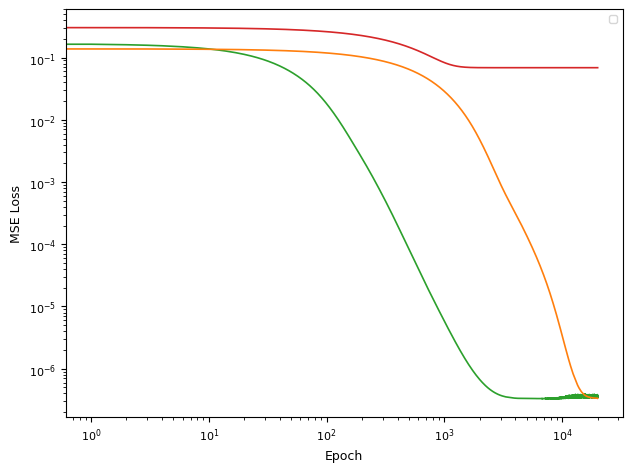

In [482]:
@dataclass(frozen=True, eq=True)
class Config():
    n: int
    B: int
    lr: float
    sparsity: float
    num_epochs: int
    dataset_size: int
    noise_mag: float
    seed: int = 42
    models_to_run: tuple = field(default_factory=lambda: (go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)))
    toy_model_type: type = DatasetModel
    random_target_generator: callable = generate_birkhoff_using_SK
    
    
    def cleaned_tuple(self):
        return (
            self.n,
            self.B,
            self.lr,
            self.sparsity,
            self.num_epochs,
            self.dataset_size,
            self.noise_mag,
            self.seed,
            tuple(self.models_to_run),  # Convert list to tuple for hashing
            self.toy_model_type.__name__,  # Use class name for hashing
            self.random_target_generator.__name__  # Use function name for hashing
        )
        
@file_cache('toy_model_cache.pkl')
def run_single_experiment(config:Config, show_tqdm=True):
    """
    Runs one training session with a specific configuration.
    Returns the final metrics and history for plotting.
    """
    # 1. Setup local hyperparams from config
    n = config.n
    B = config.B
    lr = config.lr
    sparsity = config.sparsity
    num_epochs = config.num_epochs
    dataset_size = config.dataset_size
    noise_mag = config.noise_mag
    
    seed = config.seed
    np.random.seed(seed)
    torch.manual_seed(seed)
        
    toy_model_type = config.toy_model_type # TODO
    random_target_generator = config.random_target_generator # TODO
    
    T = random_target_generator(n, batch_size=B, device='cpu')  # Generate target bistochastic matrices
    
    models_to_run = config.models_to_run
    
    exp_models = {model_dataclass.name: build_model(model_dataclass, n, B) for model_dataclass in models_to_run}
    exp_models = {name: model for name, model in exp_models.items() if model is not None}
    
    toy_models = {
        name: toy_model_type(model=m, targets=T, d=n, batch_size=B, dataset_size=dataset_size, sparsity=sparsity, noise_mag=noise_mag) for name, m in exp_models.items()
    }

    # 4. Optimization Setup
    criterion = nn.MSELoss(reduction='none')
    criterion_mean_over_dim = (1, 2) if toy_model_type.Y_Ytilde_shape == "mat" else ()
    if toy_model_type.Y_Ytilde_type == "complex":
        criterion = lambda Y, Ytilde: torch.abs(Y - Ytilde)**2
    
    adam_params = dict(lr=lr, eps=1e-6)
    
    optimizers = {
        name: optim.Adam(toy_model.parameters(), **adam_params) for name, toy_model in toy_models.items()
    }
    
    # 5. Training Loop
    local_history = {name: np.zeros((B, num_epochs)) for name in exp_models.keys()}
    
    for epoch in tqdm.tqdm(range(num_epochs), disable=not show_tqdm):
        for name in exp_models.keys():

            opt = optimizers[name]
            opt.zero_grad()
            
            individual_losses = criterion(*toy_models[name].get_Y_YTilde())
            # print("individual_losses", individual_losses)
            loss=torch.mean(individual_losses)

            # loss = criterion(Y, model())
            loss.backward()
            opt.step()
            
            with torch.no_grad():
                local_history[name][:,epoch] = individual_losses.mean(axis=criterion_mean_over_dim).detach().cpu().numpy()
            
    # Return final loss for each model as a summary
    summary = {f"final_loss_{k}": v[-1] for k, v in local_history.items()}
    summary.update({f"final_forward_output_{k}": toy_models[k].get_doubly_stochastic_matrix().detach().cpu().numpy() for k in local_history.keys()})
    return summary, local_history

config = Config(
    n=4,
    B=64,
    lr=0.001,
    sparsity=0.0,
    num_epochs=20_000, #0_000,
    dataset_size=64,
    noise_mag=1e-3,
    models_to_run=(go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)),
    toy_model_type=DatasetModel,
    random_target_generator=generate_birkhoff_using_SK
)
test = run_single_experiment(config)[1]

plt.plot(
    test['go-$m$HC ($s=2$, Q)'].T.mean(axis=1), color='tab:green'
)


plt.plot(
    test['$m$HC-lite'].T.mean(axis=1), color='tab:orange'
)


plt.plot(
    test['KromHC'].T.mean(axis=1), color='tab:red'
)

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

# HERE

Text(0, 0.5, 'MSE Loss')

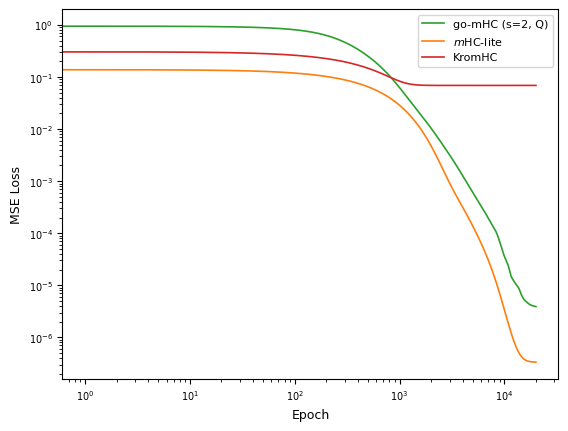

In [344]:
plt.plot(
    test['go-$m$HC ($s=2$, Q)'].T.mean(axis=1), color='tab:green', label='go-mHC (s=2, Q)'
)


plt.plot(
    test['$m$HC-lite'].T.mean(axis=1), color='tab:orange', label='$m$HC-lite'
)


plt.plot(
    test['KromHC'].T.mean(axis=1), color='tab:red', label='KromHC'
)

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

In [226]:
@dataclass
class ConfigSweep():
    n: list
    noise_mag: list = field(default_factory=lambda: [1e-4])
    B: list = field(default_factory=lambda: [64])
    lr: list = field(default_factory=lambda: [0.001])
    sparsity: list = field(default_factory=lambda: [0.0])
    num_epochs: list = field(default_factory=lambda: [10_000])
    dataset_size: list = field(default_factory=lambda: [100])
    seed: list = field(default_factory=lambda: [42])
    models_to_run: list = field(default_factory=lambda: (go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)))
    toy_model_type: type = DatasetModel
    random_target_generator: callable = generate_birkhoff_using_SK
    
    def __getitem__(self, idx):
        if isinstance(idx, str):
            return getattr(self, idx)
        else:
            raise KeyError("ConfigSweep only supports string keys corresponding to its fields.")
    
def run_experiment_sweep(config_sweep: ConfigSweep, double_tqdm=False):
    # Create a list of all combinations of hyperparameters
    keys = ['n', 'B', 'lr', 'sparsity', 'num_epochs', 'dataset_size', 'noise_mag', 'seed']
    values = [getattr(config_sweep, key) for key in keys]
    
    all_combinations = list(itertools.product(*values))
    
    print(f"Running {len(all_combinations)} experiments...")
    
    results = []
    
    for idx, combination in tqdm.tqdm(enumerate(all_combinations), disable=not double_tqdm):
        print(f"Running experiment {idx + 1}/{len(all_combinations)}")
        config_dict = dict(zip(keys, combination))
        config = Config(**config_dict, models_to_run=config_sweep.models_to_run, toy_model_type=config_sweep.toy_model_type, random_target_generator=config_sweep.random_target_generator)
        summary, history = run_single_experiment(config, show_tqdm=double_tqdm)
        results.append((config_dict, summary, history))
    
    return results

# Karpelevic Shadow

Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0828+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0821+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0814+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0806+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0799+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0792+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0784+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0777+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0770+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0763+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0755+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.1000+0.0500j]) Ytilde tensor([0.0748+0.j], grad_fn=<IndexBackward0>)
Y tensor([-0.100

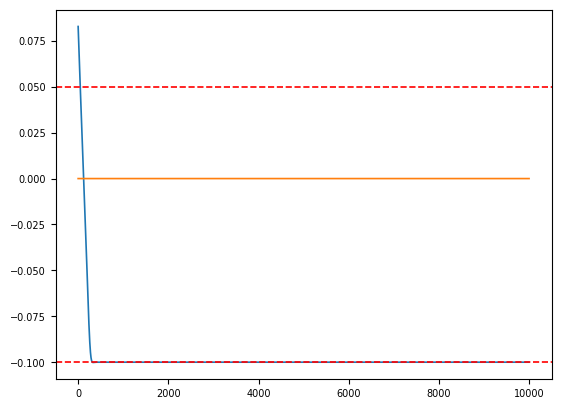

In [235]:
from torch import optim
toy_model = TargetEigenvalueModel(
    model=GeneralizedUnistochastic(d=3, s=2, batch_size=1), 
    targets=torch.tensor([-0.1 + 0.05j], dtype=torch.complex64),
    d=3, batch_size=1
)

opt = torch.optim.Adam(toy_model.model.parameters(), lr=1e-4)

res = []
for epoch in range(10_000):
    Y, Ytilde = toy_model.get_Y_YTilde()
    res.append(Ytilde.detach().cpu().numpy())
    
    opt.zero_grad()
    print("Y", Y, "Ytilde", Ytilde)
    loss = torch.abs(Y - Ytilde)**2
    loss.backward()
    opt.step()
    
toy_model.get_Y_YTilde()

plt.plot(np.array(res).real.flatten())
plt.plot(np.array(res).imag.flatten())
plt.axhline(toy_model.target_eigvals[0].real.item(), color='red', linestyle='dashed')
plt.axhline(toy_model.target_eigvals[0].imag.item(), color='red', linestyle='dashed')

In [154]:
generate_random_eigval_targets_complex_square(3, batch_size=5)

tensor([-0.3943+0.5193j, -0.1992-0.1466j,  0.4211+0.9104j,  0.8617+0.6837j,
         0.0825+0.4434j])

In [266]:
# TargetEigenvalueModel(
#     model=GeneralizedUnistochastic(d=3, s=3, batch_size=2), 
#     target_eigvals=generate_random_eigval_targets_unit_circle(d=3, batch_size=2), 
#     d=3, batch_size=2
# ).get_Y_YTilde()

sweep_config = Config(
    n=3,
    B=51**2,
    lr=0.001,
    sparsity=0.0,
    num_epochs=1000,
    dataset_size=10,
    noise_mag=0, #1e-3,
    seed=42,
    models_to_run=(go_mHC_run(s=1, orthonormal=False), ),
    toy_model_type=TargetEigenvalueModel,
    random_target_generator=generate_grid_eigval_targets_complex_square#generate_random_eigval_targets_complex_square #generate_random_eigval_targets_unit_circle
)

results = run_single_experiment(sweep_config)

Loading result from cache file: toy_model_cache.pkl


100%|██████████| 1000/1000 [00:26<00:00, 37.68it/s]


Computed result and saved to cache file: toy_model_cache.pkl


In [ ]:
51**2

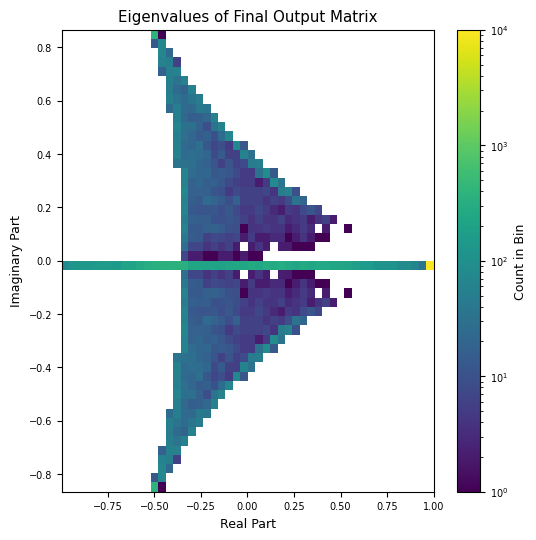

In [268]:
from matplotlib.colors import LogNorm
eigs = torch.linalg.eigvals(torch.Tensor(results[0]["final_forward_output_go-$m$HC ($s=1$, U)"]))

# plot hist2d of real vs imag parts of eigs
plt.figure(figsize=(6, 6))
plt.hist2d(eigs.real.cpu().numpy().flatten(), eigs.imag.cpu().numpy().flatten(), bins=50, cmap='viridis', norm=LogNorm())
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues of Final Output Matrix')
plt.colorbar(label='Count in Bin')

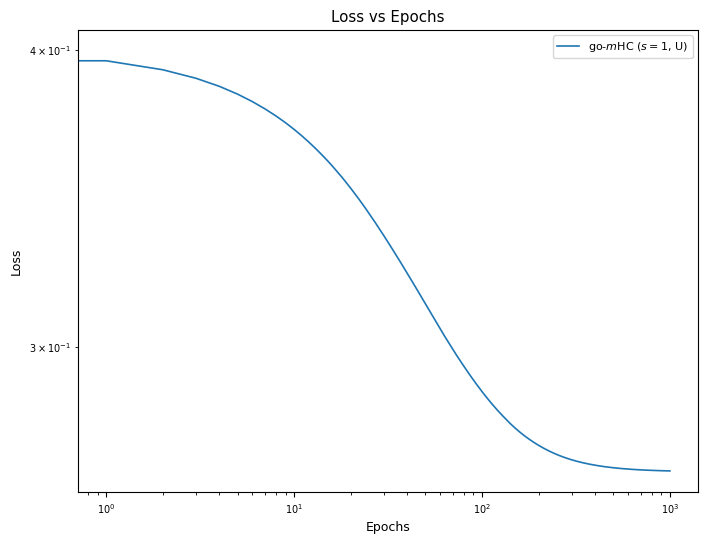

In [269]:
# plot loss vs epochs with error bars for each model
plt.figure(figsize=(8, 6))
for model_name in results[1].keys():
    history = results[1][model_name]
    mean_loss = history.mean(axis=0)
    std_loss = history.std(axis=0)
    epochs = np.arange(len(mean_loss))
    plt.plot(epochs, mean_loss, label=model_name)
    plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)
    
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.show()

# Loss Trajectories by # of residual streams and sparsity

In [393]:
# Takes 36mins on MBP 2021 - M1 Pro
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 7, 8, 10, 12, 16],
    sparsity=[0, 0.5, 0.9],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

Running 30 experiments...
Running experiment 1/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/30
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 12/30
True
Loading result from cache file: toy_model_cache.pkl

/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


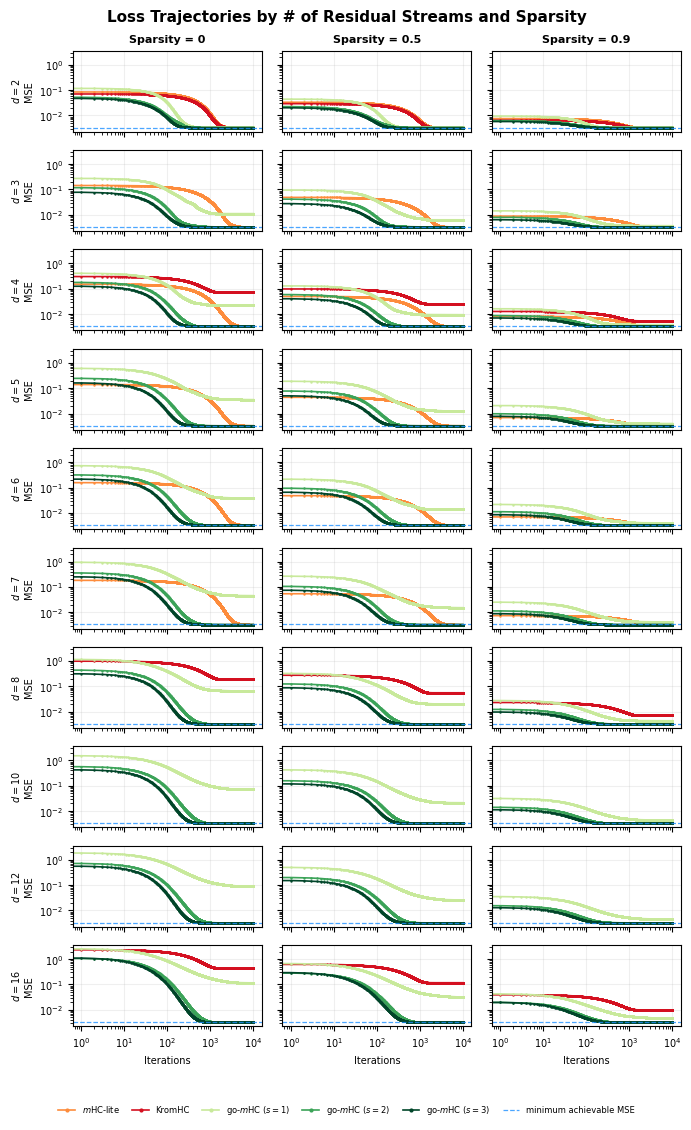

In [394]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 3.25)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})

# --- DATA MAPPING ---
# Create a lookup for results based on (n, sparsity)
# results is the list returned by run_experiment_sweep
results_lookup = {(c['n'], c['sparsity']): h for c, s, h in results}

# Extract unique values in the order they appear to maintain grid structure
n_values = sorted(list(set(c['n'] for c, s, h in results)))
sparsity_values = sorted(list(set(c['sparsity'] for c, s, h in results)))

# Using the first config to set noise floor
first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3)), "dodgerblue"]

n_rows = len(n_values)
n_cols = len(sparsity_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=FIG_SIZE, sharex=True, sharey=True)

# Ensure axes is always 2D even for 1x1 cases
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes[np.newaxis, :]
elif n_cols == 1:
    axes = axes[:, np.newaxis]

for col, s in enumerate(sparsity_values):
    axes[0, col].set_title(f"Sparsity = {s}", fontsize=8, fontweight='bold')

for row, d in enumerate(n_values):
    for col, s in enumerate(sparsity_values):
        ax = axes[row, col]
        
        # Get history from our lookup table
        history = results_lookup.get((d, s), {})
        # print(history.keys())

        histories = {
            '$m$HC-lite': [],
            'KromHC': [],
            ' ': [],
            'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
            'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
            'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', []),
        }
        
        if 'KromHC' in history:
            histories['KromHC'] = history.get('KromHC', [])
        # if 'KromHC ik=4' in history:
        #     histories['KromHC ($i_k=4$)'] = history.get('KromHC ik=4', [])
        if '$m$HC-lite' in history:
            histories['$m$HC-lite'] = history.get('$m$HC-lite', [])

        i = 0
        for label in histories:
            data = histories[label]
            # if data is not None and (hasattr(data, '__len__') and len(data) > 0):
            avg_data = np.mean(data, axis=0)
            # print(label, avg_data.shape)
            ax.plot(avg_data, color=colors[i],
                    alpha=0 if label == " " else 1,
                    marker='.', markersize=1.5, rasterized=True)
            i += 1

        # Noise floor line
        ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.grid(True, which="major", ls="-", alpha=0.2)

        if col == 0:
            ax.set_ylabel(f"$d={d}$\nMSE", fontsize=7)
        if row == n_rows - 1:
            ax.set_xlabel("Iterations", fontsize=7)

# --- LEGEND ---
legend_labels = ['$m$HC-lite', 'KromHC', 'go-$m$HC ($s=1$)',
                 'go-$m$HC ($s=2$)', 'go-$m$HC ($s=3$)', 'minimum achievable MSE']
legend_colors = [colors[0], colors[1], colors[3], colors[4], colors[5]]

handles = [Line2D([0], [0], color=c, marker='.', markersize=4, lw=1.2, label=l)
           for c, l in zip(legend_colors, legend_labels[:-1])]

handles.append(Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8,
                       label='minimum achievable MSE'))

fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.01),
           ncol=len(handles),
           frameon=False,
           fontsize=6,
           columnspacing=1.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# make suptitle closer to the plots
fig.suptitle("Loss Trajectories by # of Residual Streams and Sparsity",
             fontsize=11, fontweight='bold', y=0.97)

# plt.savefig('loss_traj_sparsity_grid.pdf', bbox_inches='tight', dpi=300)
plt.show()

# MSE by matrix dimension

In [391]:
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16],
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

Running 11 experiments...
Running experiment 1/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/11
True
Loading result from cache file: toy_model_cache.pkl


noise_floor 0.003333333333333334


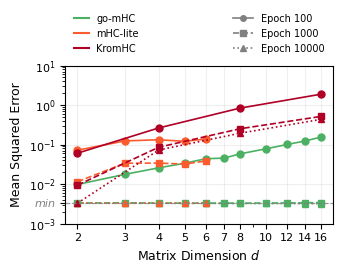

In [392]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

# Get noise floor and dims from the new results structure
# Assuming all experiments in this sweep share the same noise_mag
first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in results)))

print("noise_floor", noise_floor)

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC': plt.cm.YlOrRd(0.9),
}
epoch_indices = [99, 999, 9999]
epoch_markers = {99: 'o', 999: 's', 9999: '^'}
epoch_linestyles = {99: '-', 999: '--', 9999: ':'}

def get_loss_at_epoch(avg_history, epoch_idx):
    if avg_history is None or len(avg_history) == 0:
        return None
    if epoch_idx >= len(avg_history):
        return avg_history[-1] # Return last available if index is out of bounds
    return avg_history[epoch_idx]

fig, ax = plt.subplots(figsize=FIG_SIZE)

# Map methods to their keys in the history dictionary
method_map = {
    'go-mHC': 'go-$m$HC ($s=2$, Q)',
    'mHC-lite': '$m$HC-lite',
    'KromHC': 'KromHC'
}

for method_name, history_key in method_map.items():
    color = colors_methods[method_name]
    
    for epoch in epoch_indices:
        xs = []
        ys = []
        
        for d in dims:
            # Find the history for this specific dimension d
            # (Assuming sparsity/other params are constant for this specific plot)
            current_hist = None
            for config, summary, history in results:
                if config['n'] == d:
                    current_hist = history.get(history_key)
                    break
            
            if current_hist is None or len(current_hist) == 0:
                continue
                
            # Filter logic from original code
            if method_name == 'KromHC' and d.bit_count() != 1:
                continue
            if method_name == 'mHC-lite' and d >= 7:
                continue
                
            avg_hist = np.mean(current_hist, axis=0)
            val = get_loss_at_epoch(avg_hist, epoch)
            
            if val is not None:
                xs.append(d)
                ys.append(val)
        
        if xs:
            ax.plot(xs, ys,
                    color=color,
                    marker=epoch_markers[epoch],
                    linestyle=epoch_linestyles[epoch],
                    markersize=5,
                    rasterized=True)

ax.axhline(y=noise_floor, color='gray', linestyle='--', linewidth=0.9, alpha=0.8)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# --- Inject noise_floor into y-ticks ---
ax.set_ylim(1e-3, 1e1)
plt.draw() # Force draw to populate ticks

existing_ticks = ax.get_yticks()
# Filter ticks to keep them within a reasonable range and add noise floor
new_ticks = np.unique(np.append(existing_ticks[(existing_ticks >= 1e-3) & (existing_ticks <= 1e1)], noise_floor))
new_ticks.sort()

# Create labels manually to handle 'min'
new_labels = []
for t in new_ticks:
    if np.isclose(t, noise_floor):
        new_labels.append('min')
    else:
        new_labels.append(f'$10^{{{int(np.log10(t))}}}$' if t > 0 else '0')

ax.set_yticks(new_ticks)
ax.set_yticklabels(new_labels)

# Style the "min" tick label distinctively
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() == 'min':
        tick_label.set_color('gray')
        tick_label.set_fontstyle('italic')

ax.set_xlabel("Matrix Dimension $d$")
ax.set_ylabel("Mean Squared Error")
ax.grid(True, which="major", ls="-", alpha=0.2)

# --- Two-column legend above the plot ---
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC']
]
epoch_handles = [
    Line2D([0], [0], color='gray', marker=epoch_markers[e],
           linestyle=epoch_linestyles[e], lw=1.2, markersize=4, label=f'Epoch {e+1}')
    for e in epoch_indices
]

legend1 = ax.legend(handles=method_handles,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=1.5)
legend2 = ax.legend(handles=epoch_handles,
                    loc='lower right',
                    bbox_to_anchor=(1.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=2.0)
ax.add_artist(legend1)

plt.savefig('mse_vs_dim_high_noise.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Time to convergence by matrix dimension

In [569]:
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16],
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
    # models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

sweep_config = ConfigSweep(
    n=[20, 24, 28, 32, 40, 48, 56, 64],
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
    # models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results2 = run_experiment_sweep(sweep_config)

results_combined = results + results2
results = results_combined

Running 11 experiments...
Running experiment 1/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/11
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/11
Loading result from cache file: toy_model_cache.pkl
Running 8 experiments...
Running experiment 1/8
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:36<00:00, 272.71it/s]


Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 2/8
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:37<00:00, 264.46it/s]


Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 3/8
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:44<00:00, 225.34it/s]


Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 4/8
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/8
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/8
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/8
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/8
Loading result from cache file: toy_model_cache.pkl


In [570]:
results = results_combined

Noise floor: 3.333333e-03
5% threshold for convergence to noise floor: 3.500000e-03

go-mHC:

mHC-lite:

KromHC (higher loss):


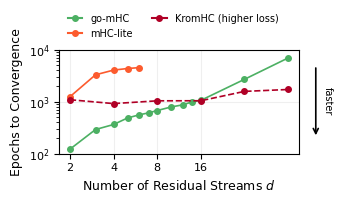

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.6)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

# Extract noise floor and dimensions from results
first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in results)))


colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    'KromHC': plt.cm.YlOrRd(0.9)
}

def get_convergence_epoch(history_list, threshold_frac=0.05):
    if history_list is None or len(history_list) == 0:
        return None
    final_loss = history_list[-1]
    if final_loss is None:
        return None
    cutoff = final_loss * (1 + threshold_frac)
    for i, val in enumerate(history_list):
        if val is not None and val <= cutoff:
            return i
    return None

fig, ax = plt.subplots(figsize=FIG_SIZE)

print(f"Noise floor: {noise_floor:.6e}")
print(f"5% threshold for convergence to noise floor: {noise_floor * 1.05:.6e}")
print("=" * 70)

# Mapping method display names to the keys inside the history objects
method_map = [
    ('go-mHC', 'go-$m$HC ($s=2$, Q)'),
    ('mHC-lite', '$m$HC-lite'),
    ('KromHC (higher loss)', 'KromHC'),
]

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs = []
    ys = []
    reached_floor = []

    print(f"\n{method_name}:")
    for d in dims:
        # Find history for this dimension
        hist = None
        for config, summary, history in results:
            if config['n'] == d:
                hist = history.get(history_key, [])
                break
        
        # Method-specific filters
        if 'KromHC' in method_name and d.bit_count() != 1:
            continue
        if method_name == 'mHC-lite' and d >= 7:
            continue
        
        if hist is None or len(hist) == 0:
            continue

        # Calculate convergence per seed/run
        conv_epochs = []
        for single_hist in hist:
            single_conv_epoch = get_convergence_epoch(single_hist)
            if single_conv_epoch is not None:
                conv_epochs.append(single_conv_epoch)
        
        avg_conv_epoch = np.mean(conv_epochs) if conv_epochs else None
        
        # Calculate final loss (mean of the minimums across seeds)
        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None
        at_floor = final_loss is not None and final_loss <= noise_floor * 1.05

        if avg_conv_epoch is not None:
            xs.append(d)
            ys.append(avg_conv_epoch)
            reached_floor.append(at_floor)

    if xs:
        # Solid if all points reached the floor, dashed if any failed
        all_at_floor = all(reached_floor)
        ls = '-' if all_at_floor else '--'

        ax.plot(xs, ys,
                color=color,
                marker='o',
                linestyle=ls,
                markersize=4,
                label=method_name,
                rasterized=True)

# Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticks([100, 1000, 10000])

ax.set_xlabel("Number of Residual Streams $d$")
ax.set_ylabel("Epochs to Convergence")
ax.grid(True, which="major", ls="-", alpha=0.2)

# --- Legend ---
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, marker='o', markersize=4,
           label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC (higher loss)']
]

ax.legend(handles=method_handles,
          loc='lower left', bbox_to_anchor=(0, 1.02),
          ncol=2, frameon=False, fontsize=7, handlelength=1.5)

# --- Faster Arrow Annotation ---
ax.annotate(
    '',
    xy=(1.07, 0.15),          
    xytext=(1.07, 0.85),      
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    annotation_clip=False,    
)

ax.annotate(
    'faster',
    xy=(1.10, 0.5),           
    xycoords='axes fraction',
    fontsize=7,
    va='center',
    ha='left',
    rotation=270,             
    annotation_clip=False,
)

plt.xticks([2**i for i in range(1, 5)], [str(2**i) for i in range(1, 5)])
# no x minor ticks
ax.set_xticks([], minor=True)

plt.savefig('final_convergence_vs_dim.pdf', bbox_inches='tight', dpi=300)
plt.show()

[]

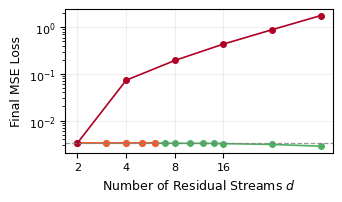

In [556]:
# plot the final losses
fig, ax = plt.subplots(figsize=FIG_SIZE)

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs = []
    ys = []

    for d in dims:
        hist = None
        for config, summary, history in results:
            if config['n'] == d:
                hist = history.get(history_key, [])
                break
        
        if 'KromHC' in method_name and d.bit_count() != 1:
            continue
        if method_name == 'mHC-lite' and d >= 7:
            continue
        
        if hist is None or len(hist) == 0:
            continue

        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None

        if final_loss is not None:
            xs.append(d)
            ys.append(final_loss)

    if xs:
        ax.plot(xs, ys,
                color=color,
                marker='o',
                linestyle='-',
                markersize=4,
                label=method_name,
                rasterized=True)
        
first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
ax.axhline(y=noise_floor, color='gray', linestyle='--', linewidth=0.9, alpha=0.8, label='noise floor')
ax.set_xscale('log')
ax.set_yscale('log')

ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("Number of Residual Streams $d$")
ax.set_ylabel("Final MSE Loss")
ax.grid(True, which="major", ls="-", alpha=0.2)

plt.xticks([2**i for i in range(1, 5)], [str(2**i) for i in range(1, 5)])
# no x minor ticks
ax.set_xticks([], minor=True)


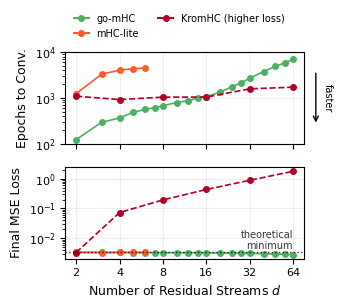

In [571]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.9) 

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

def get_convergence_epoch(history_list, threshold_frac=0.05):
    # Fixed to handle NumPy arrays correctly
    if history_list is None or np.size(history_list) == 0:
        return None
    final_loss = history_list[-1]
    cutoff = final_loss * (1 + threshold_frac)
    indices = np.where(history_list <= cutoff)[0]
    return indices[0] if indices.size > 0 else None

# Data Setup
first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in results)))

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    'KromHC': plt.cm.YlOrRd(0.9)
}

method_map = [
    ('go-mHC', 'go-$m$HC ($s=2$, Q)'),
    ('mHC-lite', '$m$HC-lite'),
    ('KromHC (higher loss)', 'KromHC'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True)

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs, ys_conv, ys_loss = [], [], []
    reached_floor = []

    for d in dims:
        hist = None
        for config, summary, history in results:
            if config['n'] == d:
                hist = history.get(history_key, [])
                break
        
        if 'KromHC' in method_name and d.bit_count() != 1: continue
        if method_name == 'mHC-lite' and d >= 7: continue
        if hist is None or np.size(hist) == 0: continue

        # Calculate metrics
        conv_list = [get_convergence_epoch(h) for h in hist]
        conv_list = [c for c in conv_list if c is not None]
        
        avg_conv = np.mean(conv_list) if conv_list else None
        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None
        at_floor = final_loss is not None and final_loss <= noise_floor * 1.05

        if avg_conv is not None and final_loss is not None:
            xs.append(d)
            ys_conv.append(avg_conv)
            ys_loss.append(final_loss)
            reached_floor.append(at_floor)

    if xs:
        # Determine shared linestyle: Solid if ALL points reached floor, dashed otherwise
        ls = '-' if all(reached_floor) else '--'
        
        # Plot to both axes with the same style
        ax1.plot(xs, ys_conv, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)
        ax2.plot(xs, ys_loss, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)

# --- Top Plot (ax1) Formatting ---
ax1.set_yscale('log')
ax1.set_ylabel("Epochs to Conv.")
ax1.grid(True, which="major", ls="-", alpha=0.2)
ax1.set_yticks([100, 1000, 10000])

# Speed Arrow
ax1.annotate('', xy=(1.05, 0.2), xytext=(1.05, 0.8), xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.0), annotation_clip=False)
ax1.annotate('faster', xy=(1.08, 0.5), xycoords='axes fraction', fontsize=7,
             va='center', rotation=270, annotation_clip=False)

# --- Bottom Plot (ax2) Formatting ---
ax2.axhline(y=noise_floor, color='k', linestyle=':', linewidth=1.0, alpha=0.8)
ax2.text(max(dims), noise_floor*2.5, 'theoretical\nminimum', va='center', ha='right', fontsize=7, color='k', alpha=0.8)
ax2.set_yscale('log')
ax2.set_ylabel("Final MSE Loss")
ax2.set_xlabel("Number of Residual Streams $d$")
ax2.grid(True, which="major", ls="-", alpha=0.2)

# --- X-Axis Consistency ---
ax2.set_xscale('log')
tick_vals = [2**i for i in range(1, int(np.log2(max(dims))) + 1)]
ax2.set_xticks(tick_vals)
ax2.set_xticklabels([str(v) for v in tick_vals])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xticks([], minor=True)

# --- Unified Legend ---
# We use a custom function to create handles that match the linestyle logic
legend_handles = []
for m, _ in method_map:
    # Check if this specific method was dashed (simplified check for legend)
    # In a perfect world, we'd store the ls used in the loop, but this is clean:
    legend_handles.append(Line2D([0], [0], color=colors_methods[m], lw=1.5, 
                                 marker='o', markersize=4, label=m))

ax1.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(0, 1.05),
           ncol=2, frameon=False, fontsize=7, handlelength=1.5)

plt.savefig('final_convergence_vs_dim.pdf', bbox_inches='tight', dpi=300)
plt.show()

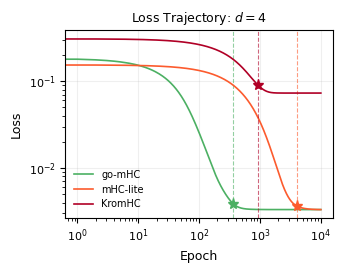

In [ ]:
def plot_loss_trajectory(d):
    """
    Plot loss trajectories for all models at a given matrix dimension d.
    Now uses the 'results' list from run_experiment_sweep.
    """
    # Find the specific experiment in results that matches dimension d
    experiment_data = None
    for config, summary, history in results:
        if config['n'] == d:
            experiment_data = history
            break
    
    if experiment_data is None:
        print(f"No experiment found for dimension d={d}")
        return

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    # Configuration for methods
    methods = [
        ('go-mHC', 'go-$m$HC ($s=2$, Q)', lambda d: False),
        ('mHC-lite', '$m$HC-lite', lambda d: d >= 7),
        ('KromHC', 'KromHC', lambda d: d.bit_count() != 1),
    ]

    for method_name, method_key, skip_fn in methods:
        if skip_fn(d):
            continue
            
        # Extract the history for this specific method (multiple seeds/runs)
        hist = experiment_data.get(method_key, [])
        
        if hist is None or len(hist) == 0:
            continue

        # Convert to numpy array for easier manipulation
        hist = np.array(hist)
        avg_hist = np.mean(hist, axis=0)
        num_epochs = avg_hist.shape[0]

        color = colors_methods.get(method_name, 'black')
        
        # Plot the average trajectory
        ax.plot(range(num_epochs), avg_hist, color=color, label=method_name, linewidth=1.2)

        # Calculate convergence points across all seeds
        conv_vals = []
        for single_hist in hist:
            conv = get_convergence_epoch(single_hist)
            if conv is not None:
                conv_vals.append(conv)
        
        if conv_vals:
            avg_conv = np.mean(conv_vals)
            avg_conv_int = int(avg_conv)
            
            # Ensure the vertical line and marker are placed correctly
            ax.axvline(x=avg_conv, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
            
            # Plot marker at the convergence point on the average line
            if avg_conv_int < len(avg_hist):
                ax.plot(avg_conv, avg_hist[avg_conv_int], 
                        marker='*', color=color, markersize=8, zorder=5)

    # Formatting
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Loss Trajectory: $d = {d}$", fontsize=9)
    ax.grid(True, which="major", ls="-", alpha=0.2)
    ax.legend(frameon=False, fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f'convergence_loss_trajectory_d_{d}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage:
# Simply pass the dimension 'd' you want to see. 
# The function will find it in the 'results' list automatically.
plot_loss_trajectory(d=4)

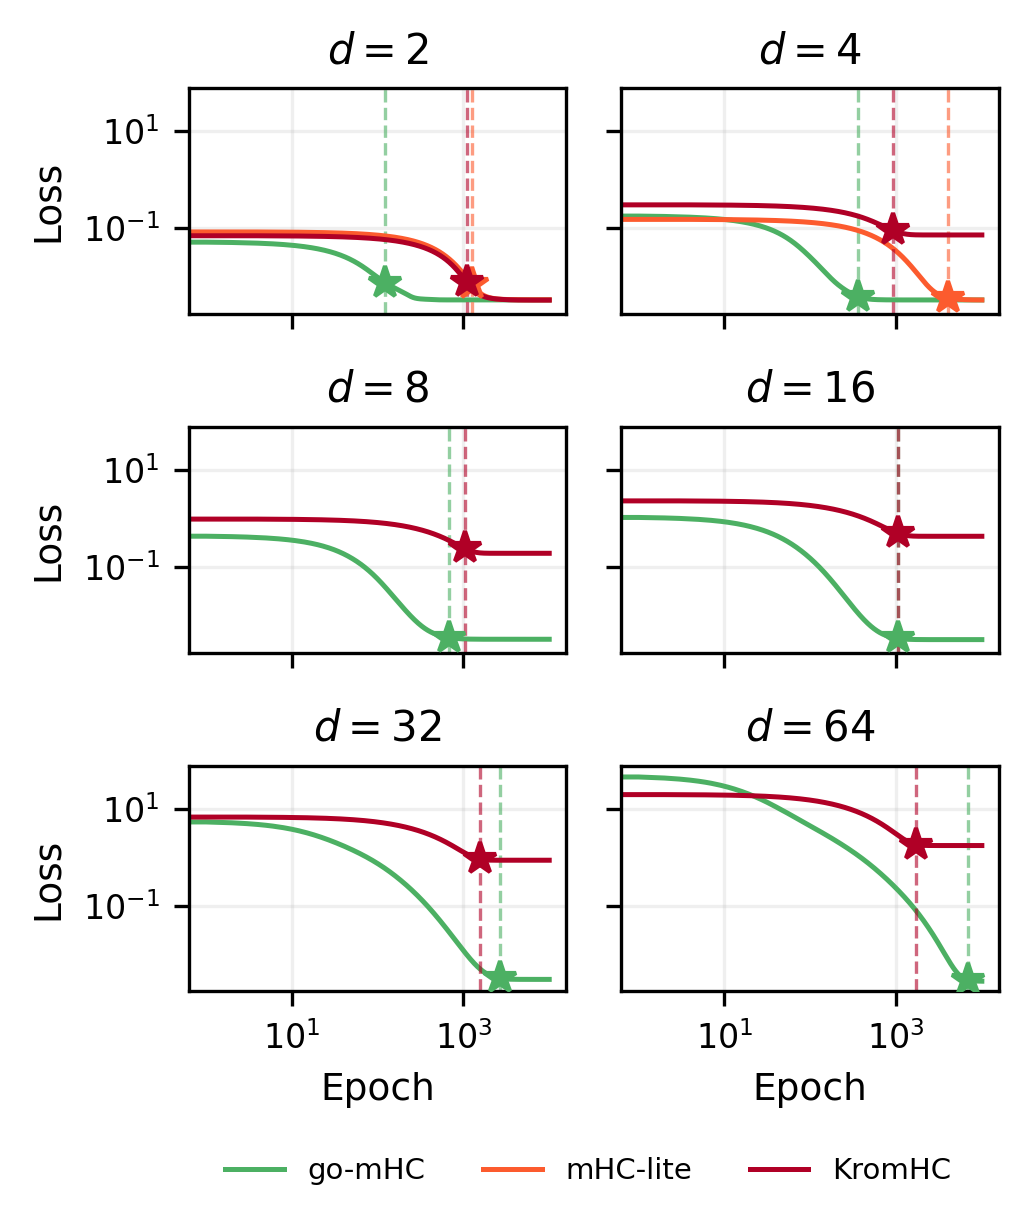

In [631]:
import matplotlib.pyplot as plt
import numpy as np

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    'KromHC': plt.cm.YlOrRd(0.9)
}

def plot_loss_trajectory_subplot(d, ax):
    """
    Plots the loss trajectory for a specific d onto a provided matplotlib axis.
    """
    # Find the specific experiment in results
    experiment_data = None
    for config, summary, history in results:
        if config['n'] == d:
            experiment_data = history
            break
    
    if experiment_data is None:
        ax.set_title(f"No data for d={d}")
        return

    # Configuration for methods
    methods = [
        ('go-mHC', 'go-$m$HC ($s=2$, Q)', lambda d: False),
        ('mHC-lite', '$m$HC-lite', lambda d: d >= 7),
        ('KromHC', 'KromHC', lambda d: d.bit_count() != 1),
    ]

    for method_name, method_key, skip_fn in methods:
        if skip_fn(d):
            continue
            
        hist = experiment_data.get(method_key, [])
        if hist is None or len(hist) == 0:
            continue

        hist = np.array(hist)
        avg_hist = np.mean(hist, axis=0)
        num_epochs = avg_hist.shape[0]
        color = colors_methods[method_name]
        
        # Plot average trajectory
        ax.plot(range(num_epochs), avg_hist, color=color, label=method_name, linewidth=1.2)

        # Convergence logic
        conv_vals = [get_convergence_epoch(h) for h in hist if get_convergence_epoch(h) is not None]
        
        if conv_vals:
            avg_conv = np.mean(conv_vals)
            idx = min(int(avg_conv), len(avg_hist) - 1)
            ax.axvline(x=avg_conv, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
            ax.plot(avg_conv, avg_hist[idx], marker='*', color=color, markersize=8, zorder=5)

    # Formatting for the subplot
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d = {d}$", fontsize=10)
    ax.grid(True, which="major", ls="-", alpha=0.2)
    
    # Only show labels on the outer edges to save space
    ax.tick_params(axis='both', which='major', labelsize=8)

# --- Grid Generation ---
dimensions = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(3, 2, figsize=(COLUMN_WIDTH, COLUMN_WIDTH * 1.2), sharex=True, sharey=True, dpi=300)
axes_flat = axes.flatten()

for i, d in enumerate(dimensions):
    plot_loss_trajectory_subplot(d, axes_flat[i])
    # Add labels only to specific plots to keep it clean
    if i >= 4: axes_flat[i].set_xlabel("Epoch")
    if i % 2 == 0: axes_flat[i].set_ylabel("Loss")
    
    # if d == 4:
    #     for spine in axes_flat[i].spines.values():
    #         spine.set_linewidth(2.0)
    #         spine.set_edgecolor('blue') # Makes it very obvious
    #         spine.set_zorder(10)       # Ensures the border stays on top

# Add a single legend for the entire figure at the bottom
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.57, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.suptitle("Loss Trajectories across Dimensions", fontsize=14, y=0.98)
plt.savefig('convergence_indiv_loss_trajectory.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Loss Trajectories by # of residual streams

In [395]:
# same as previous cell, using new code
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 8, 10, 12, 14, 16],
    noise_mag=[1e-1],
    num_epochs=[10_000],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4)) #[go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), KromHC_run(), mHC_lite_run()],
)

# all_results, all_histories
results = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 10 experiments...


0it [00:00, ?it/s]

Running experiment 1/10
True
Loading result from cache file: toy_model_cache.pkl


1it [00:00,  2.02it/s]

Running experiment 2/10
True
Loading result from cache file: toy_model_cache.pkl


...

8it [00:02,  4.01it/s]

Running experiment 9/10
True
Loading result from cache file: toy_model_cache.pkl


9it [00:02,  4.01it/s]

Running experiment 10/10
True
Loading result from cache file: toy_model_cache.pkl


10it [00:02,  3.68it/s]


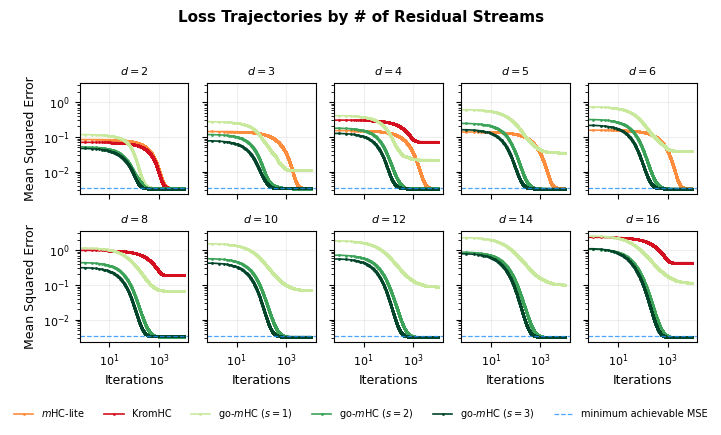

In [396]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
# Adjusted for a 2x5 grid
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 1.2)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})

# Get noise floor from the first result's config
first_config, _, _ = results[0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

# Create the 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=FIG_SIZE, sharex=True, sharey=True)
axes_flat = axes.flatten()

fig.suptitle("Loss Trajectories by # of Residual Streams", fontsize=11, fontweight='bold')

# Loop through the results list (which contains config, summary, and history)
for idx, (config_dict, summary, history) in enumerate(results):
    if idx >= len(axes_flat):
        break # Safety check if results exceed 10 subplots
        
    ax = axes_flat[idx]
    n_val = config_dict['n']

    # Map the history keys
    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
        'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', [])
    }
    
    # Conditional logic based on hyperparameters
    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plot each line
    for i, (label, data) in enumerate(plot_data_map.items()):
        # if data is not None and len(data) > 0:
        avg_data = np.mean(data, axis=0)
        ax.plot(avg_data, 
                label=label, 
                color=colors[i],
                alpha=0 if label == " " else 1, 
                marker='.', 
                markersize=2, 
                rasterized=True)

    # Plot noise floor line
    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    # Subplot formatting
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d={n_val}$", fontsize=8)
    ax.grid(True, which="major", ls="-", alpha=0.2)

    # Label only the outer plots for cleanliness
    if idx >= 5: # Bottom row
        ax.set_xlabel("Iterations")
    if idx % 5 == 0: # Left column
        ax.set_ylabel("Mean Squared Error")

# --- Legend Logic ---
# Extract handles from one of the populated axes
handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l.strip()]

# Append noise floor handle manually
filtered.append((
    Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8),
    'minimum achievable MSE'
))

# Create a single shared legend at the bottom
fig.legend(*zip(*filtered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(filtered),
           frameon=False,
           fontsize=7,
           columnspacing=2)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('appendix_loss_trajectories_by_residual_streams.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Single Loss Curve

In [397]:
# same as previous cell, using new code
sweep_config = ConfigSweep(
    n=[4],
    noise_mag=[1e-1],
    num_epochs=[10_000],
    models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), KromHC_run(), mHC_lite_run()],
)

# all_results, all_histories
results = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 1 experiments...


0it [00:00, ?it/s]

Running experiment 1/1
True
Loading result from cache file: toy_model_cache.pkl


1it [00:00,  3.33it/s]


/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


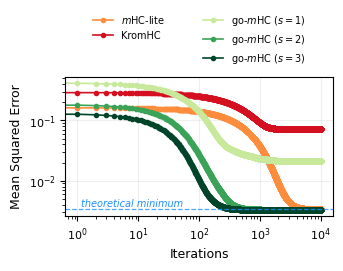

In [398]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5  
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,            
    "font.size": 9,                 
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True       
})

# Assuming 'results' is what was returned by run_experiment_sweep(config_sweep)
# We extract the noise floor from the first experiment's config for the plot
first_config, _, _ = results[0]
noise_floor = (first_config['noise_mag'] ** 2) / 3

# Define colors
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

# Iterate through each experiment result
for i, (config_dict, summary, history) in enumerate(results):
    plt.figure(figsize=FIG_SIZE)
    
    # Map the history keys based on your new data structure
    # history is the 'hist' returned by run_single_experiment
    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
        'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', [])
    }
    
    # Logic for conditional methods based on the current experiment's config
    n_val = config_dict['n']
    
    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])

    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plotting loop
    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        avg_data = np.mean(data, axis=0)
        # print(f'Exp {i} - {label} avg_data shape: ', np.shape(avg_data))
        
        plt.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    rasterized=True)

    # Plot noise floor
    plt.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    # Formatting
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error")
    plt.grid(True, which="major", ls="-", alpha=0.2)

    # --- Annotate noise floor line ---
    ax = plt.gca()
    ax.annotate('theoretical minimum', 
                xy=(0.46, noise_floor - 0.0005), 
                xycoords=('axes fraction', 'data'),
                xytext=(-4, 4), 
                textcoords='offset points',
                ha='right', 
                va='bottom',
                color='dodgerblue', 
                fontstyle='italic', 
                fontsize=7)

    # Build legend
    plt.legend(loc='lower center', 
               bbox_to_anchor=(0.5, 1.02), 
               ncol=2, 
               frameon=False, 
               fontsize=7, 
               columnspacing=4)

    # Save and show for each experiment configuration
    # Added experiment index to filename to prevent overwriting
    # plt.savefig(f'loss_trajectory_exp_{i}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Try different generated target matrix methods

True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl


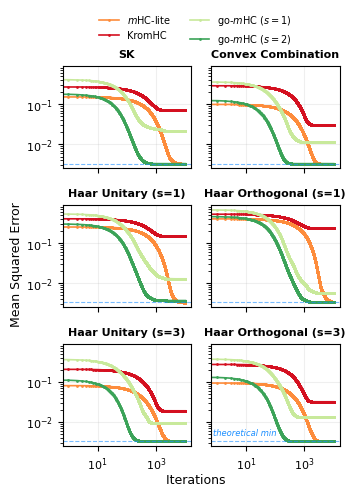

In [399]:
# 2mins
import matplotlib.pyplot as plt
import numpy as np

# Define methods to iterate over
methods = [
    generate_birkhoff_using_SK, 
    generate_birkhoff_using_BN_theorem,
    generate_birkhoff_using_haar_unitary(1), 
    generate_birkhoff_using_haar_orthogonal(1), 
    generate_birkhoff_using_haar_unitary(3), 
    generate_birkhoff_using_haar_orthogonal(3), 
]

# Create the 3x2 figure
# Adjusting height to 1.2 * COLUMN_WIDTH to accommodate 3 rows comfortably
fig, axs = plt.subplots(3, 2, figsize=(COLUMN_WIDTH, COLUMN_WIDTH * 1.3), sharex=True, sharey=True)
axs = axs.flatten()

for i, random_target_method in enumerate(methods):
    ax = axs[i]
    
    sweep_config = Config(
        n=4,
        noise_mag=1e-1,
        num_epochs=10_000,
        B=64,
        lr=0.001,
        sparsity=0,
        dataset_size=100,
        models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), KromHC_run(), mHC_lite_run()],
        random_target_generator=random_target_method
    )

    result = run_single_experiment(sweep_config)
    history = result[1]

    # Map the history keys
    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
    }

    n_val = sweep_config.n # Using config object directly

    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plotting loop on the specific axis
    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        if len(data) > 0 or label == " ":
            avg_data = np.mean(data, axis=0)
            ax.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    markersize=2, # Reduced for subplot clarity
                    rasterized=True)

    # Plot noise floor
    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.8, alpha=0.6)

    # Formatting per subplot
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(random_target_method.__name__.replace('_', ' ').replace("generate birkhoff using ", "").replace("(s", " (s").replace("BN theorem", "Convex Combination").replace("haar", "Haar").replace("unitary", "Unitary").replace("orthogonal", "Orthogonal"), fontsize=8, fontweight='bold')
    ax.grid(True, which="major", ls="-", alpha=0.2)

    # Annotate noise floor only on specific subplots to avoid clutter (e.g., the last one)
    if i == 5:
        ax.annotate('theoretical min', 
                    xy=(0.02, noise_floor / 1.2), 
                    xycoords=('axes fraction', 'data'),
                    xytext=(0, 5), 
                    textcoords='offset points',
                    ha='left', 
                    va='bottom',
                    color='dodgerblue', 
                    fontstyle='italic', 
                    fontsize=6)

# Global Labels
fig.supxlabel("         Iterations", fontsize=9)
fig.supylabel("Mean Squared Error", fontsize=9)

# Single Legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
# Filter out the empty spacer label for the legend
display_handles = [h for h, l in zip(handles, labels) if l.strip()]
display_labels = [l for l in labels if l.strip()]

fig.legend(display_handles, display_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.55, 1.07), 
           ncol=2, 
           frameon=False, 
           fontsize=7)

plt.tight_layout()

# make ylabel closer
plt.subplots_adjust(left=0.17)
plt.subplots_adjust(bottom=0.1)
plt.savefig('different_target_sampling_methods.pdf', bbox_inches='tight', dpi=300)
plt.show()

Loading result from cache file: toy_model_cache.pkl


/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Loading result from cache file: toy_model_cache.pkl
Loading result from cache file: toy_model_cache.pkl
Loading result from cache file: toy_model_cache.pkl


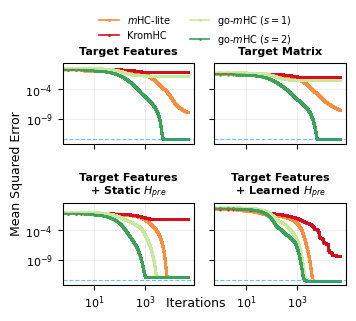

In [509]:
import matplotlib.pyplot as plt
import numpy as np

# Define methods to iterate over
toy_models = [
    DatasetModel,
    TargetMatrixModel,
    DatasetModelWithStaticHpre,
    DatasetModelWithLearnedHpre
]
toy_model_names = [
    "Target Features",
    "Target Matrix",
    "Target Features\n+ Static $H_{pre}$",
    "Target Features\n+ Learned $H_{pre}$"
]

# Create the 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(COLUMN_WIDTH, 0.8*COLUMN_WIDTH ), sharex=True, sharey=True)
axs = axs.flatten()

for i, (toy_model, toy_model_name) in enumerate(zip(toy_models, toy_model_names)):
    ax = axs[i]
    
    sweep_config = Config(
        n=4,
        noise_mag=1e-6,
        num_epochs=50_000,
        B=64,
        lr=0.001,
        sparsity=0,
        dataset_size=100,
        models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), KromHC_run(), mHC_lite_run()],
        # random_target_generator=random_target_method
        toy_model_type=toy_model
    )

    result = run_single_experiment(sweep_config)
    history = result[1]

    # Map the history keys
    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
    }

    n_val = sweep_config.n # Using config object directly

    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plotting loop on the specific axis
    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        if len(data) > 0 or label == " ":
            avg_data = np.mean(data, axis=0)
            if len(avg_data.shape) == 0:
                continue
            avg_data = np.minimum.accumulate(avg_data)
            ax.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    markersize=2, # Reduced for subplot clarity
                    rasterized=True)

    # Plot noise floor
    noise_floor = (sweep_config.noise_mag ** 2) / 3
    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.8, alpha=0.6)

    # Formatting per subplot
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(toy_model_name, fontsize=8, fontweight='bold')
    ax.grid(True, which="major", ls="-", alpha=0.2)

    # Annotate noise floor only on specific subplots to avoid clutter (e.g., the last one)
    # if i == 3:
    #     ax.annotate('theoretical min', 
    #                 xy=(0.02, noise_floor / 1.2), 
    #                 xycoords=('axes fraction', 'data'),
    #                 xytext=(0, 5), 
    #                 textcoords='offset points',
    #                 ha='left', 
    #                 va='bottom',
    #                 color='dodgerblue', 
    #                 fontstyle='italic', 
    #                 fontsize=6)

# Global Labels
fig.supxlabel("         Iterations", fontsize=9)
fig.supylabel("Mean Squared Error", fontsize=9)

# Single Legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
# Filter out the empty spacer label for the legend
display_handles = [h for h, l in zip(handles, labels) if l.strip()]
display_labels = [l for l in labels if l.strip()]

fig.legend(display_handles, display_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.55, 1.1), 
           ncol=2, 
           frameon=False, 
           fontsize=7)

plt.tight_layout()

# make ylabel closer
plt.subplots_adjust(left=0.17)
plt.subplots_adjust(right=0.98)
plt.subplots_adjust(bottom=0.1)
plt.savefig('different_toy_models_methods.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [486]:
# print keys in toy_model_cache.pkl
import pickle
with open('toy_model_cache.pkl', 'rb') as f:
    toy_model_cache = pickle.load(f)
    
print("Keys in toy_model_cache.pkl:")
copied_dict = dict(toy_model_cache)  # Create a copy to iterate over
for key in copied_dict.keys():
    # check if key has DatasetModelWithLearnedHpre in it
    if 'TargetMatrixModel' in str(key):
        print(key)
        # delete this key from the cache
        # del toy_model_cache[key]
        
# save the modified cache back to the file
# with open('toy_model_cache.pkl', 'wb') as f:
#     pickle.dump(toy_model_cache, f)

Keys in toy_model_cache.pkl:
(4, 64, 0.001, 0, 10, 100, 0.1, 42, (go_mHC_run(s=1, orthonormal=True, legend_name=''), go_mHC_run(s=2, orthonormal=True, legend_name=''), KromHC_run(ik=2, legend_name=''), mHC_lite_run(max_safe_d=7, legend_name='')), 'TargetMatrixModel', 'generate_birkhoff_using_SK')
(4, 64, 0.001, 0, 10000, 100, 0.1, 42, (go_mHC_run(s=1, orthonormal=True, legend_name=''), go_mHC_run(s=2, orthonormal=True, legend_name=''), KromHC_run(ik=2, legend_name=''), mHC_lite_run(max_safe_d=7, legend_name='')), 'TargetMatrixModel', 'generate_birkhoff_using_SK')
(4, 64, 0.001, 0, 10000, 100, 1e-05, 42, (go_mHC_run(s=1, orthonormal=True, legend_name=''), go_mHC_run(s=2, orthonormal=True, legend_name=''), KromHC_run(ik=2, legend_name=''), mHC_lite_run(max_safe_d=7, legend_name='')), 'TargetMatrixModel', 'generate_birkhoff_using_SK')
(4, 64, 0.001, 0, 10000, 100, 0.001, 42, (go_mHC_run(s=1, orthonormal=True, legend_name=''), go_mHC_run(s=2, orthonormal=True, legend_name=''), KromHC_run(i

# KromHC error with stream size

In [583]:
sweep_config = ConfigSweep(
    n=sorted([2**i for i in range(1, 9)] + [3**i for i in range(1, 6)]),
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(KromHC_run(ik=2), KromHC_run(ik=3), KromHC_run(ik=4))
)

kromhc_sweep = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 13 experiments...


0it [00:00, ?it/s]

Running experiment 1/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:06<00:00, 1663.56it/s]
1it [00:08,  8.08s/it]

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 2/13
Loading result from cache file: toy_model_cache.pkl


...

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 12/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:00<00:00, 4335197.93it/s]
12it [05:36, 35.57s/it]

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 13/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [06:30<00:00, 25.60it/s]
13it [12:09, 56.10s/it] 

Computed result and saved to cache file: toy_model_cache.pkl


In [589]:
kromhc_sweep

[({'n': 2,
   'B': 64,
   'lr': 0.001,
   'sparsity': 0,
   'num_epochs': 10000,
   'dataset_size': 100,
   'noise_mag': 0.1,
   'seed': 42},
  {'final_loss_KromHC': array([0.07228239, 0.07216924, 0.0720562 , ..., 0.00334299, 0.00334299,
          0.00334299], shape=(10000,)),
   'final_forward_output_KromHC': array([[[0.6089572 , 0.39104286],
           [0.39104286, 0.6089572 ]],
   
          [[0.58953106, 0.41046894],
           [0.41046894, 0.58953106]],
   
          [[0.67959744, 0.32040262],
           [0.32040262, 0.67959744]],
   
          [[0.48269647, 0.5173035 ],
           [0.5173035 , 0.48269647]],
   
          [[0.6569424 , 0.34305763],
           [0.34305763, 0.6569424 ]],
   
          [[0.5629347 , 0.4370653 ],
           [0.4370653 , 0.5629347 ]],
   
          [[0.31308243, 0.6869176 ],
           [0.6869176 , 0.31308243]],
   
          [[0.7225591 , 0.27744097],
           [0.27744097, 0.7225591 ]],
   
          [[0.65381825, 0.34618172],
           [0.34618172

<>:134: SyntaxWarning: invalid escape sequence '\p'
<>:134: SyntaxWarning: invalid escape sequence '\p'
/var/folders/fp/ywrwxn_122s537c0sm16gcxm0000gn/T/ipykernel_4729/183118257.py:134: SyntaxWarning: invalid escape sequence '\p'
  ax2.text(16, 16/35*3, '$\propto d$', color='k')


[2, 3, 4, 8, 9, 16, 27, 32, 64, 81, 128, 243, 256]


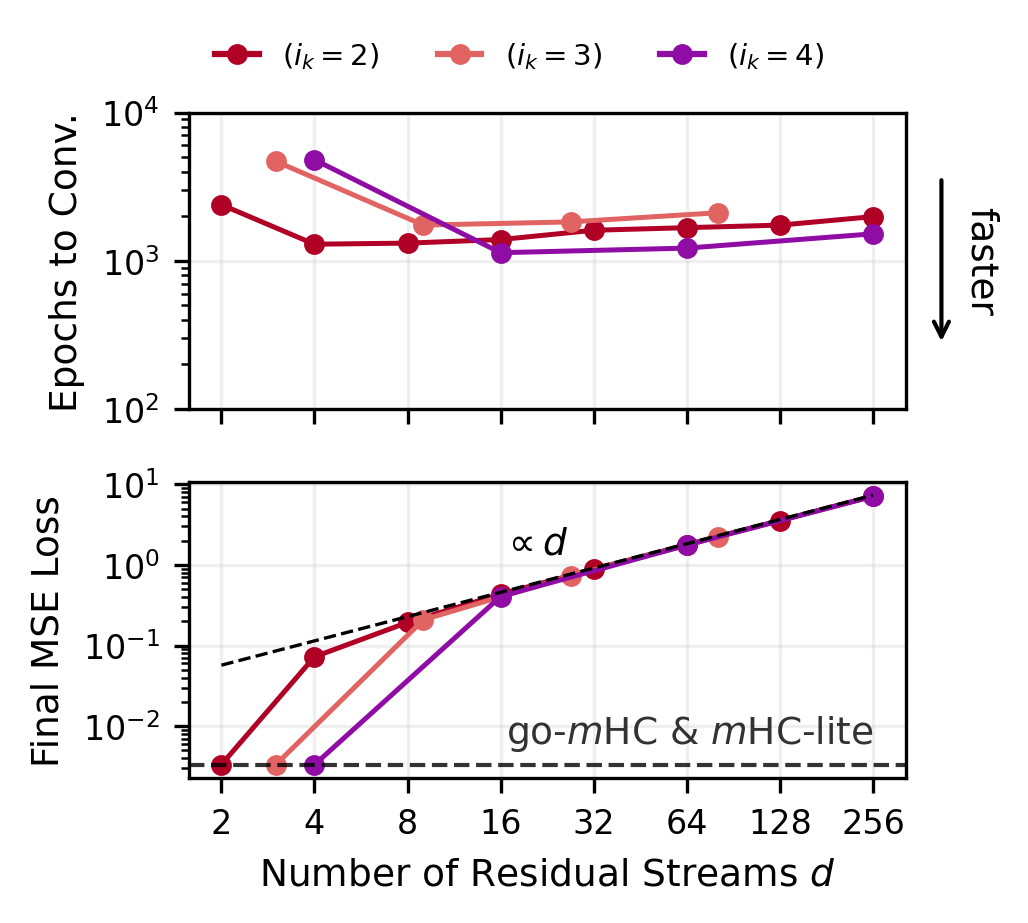

In [616]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.9) 

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

def get_convergence_epoch(history_list, threshold_frac=0.05):
    # Fixed to handle NumPy arrays correctly
    if history_list is None or np.size(history_list) == 0:
        return None
    final_loss = history_list[-1]
    cutoff = final_loss * (1 + threshold_frac)
    indices = np.where(history_list <= cutoff)[0]
    return indices[0] if indices.size > 0 else None

# Data Setup
first_config = kromhc_sweep[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in kromhc_sweep)))
print(dims)

colors_methods = {
    # 'go-mHC': plt.cm.YlGn(0.6),
    # 'mHC-lite': plt.cm.YlOrRd(0.6),
    # 'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    '($i_k=2$)': plt.cm.YlOrRd(0.9),
    '($i_k=3$)': plt.cm.plasma(0.6),
    '($i_k=4$)': plt.cm.plasma(0.3),
}

method_map = [
    ('($i_k=2$)', 'KromHC'),
    ('($i_k=3$)', 'KromHC ik=3'),
    ('($i_k=4$)', 'KromHC ik=4')
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True, dpi=300)

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs, ys_conv, ys_loss = [], [], []
    reached_floor = []

    for d in dims:
        hist = None
        for config, summary, history in kromhc_sweep:
            if config['n'] == d:
                hist = history.get(history_key, [])
                break
        
        if 'KromHC' in method_name and d.bit_count() != 1: continue
        if method_name == 'mHC-lite' and d >= 7: continue
        if hist is None or np.size(hist) == 0: continue

        # Calculate metrics
        conv_list = [get_convergence_epoch(h) for h in hist]
        conv_list = [c for c in conv_list if c is not None]
        
        avg_conv = np.mean(conv_list) if conv_list else None
        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None
        at_floor = final_loss is not None and final_loss <= noise_floor * 1.05

        if avg_conv is not None and final_loss is not None:
            xs.append(d)
            ys_conv.append(avg_conv)
            ys_loss.append(final_loss)
            reached_floor.append(at_floor)

    if xs:
        # Determine shared linestyle: Solid if ALL points reached floor, dashed otherwise
        ls = '-'# if all(reached_floor) else '--'
        
        # Plot to both axes with the same style
        ax1.plot(xs, ys_conv, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)
        ax2.plot(xs, ys_loss, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)

# --- Top Plot (ax1) Formatting ---
ax1.set_yscale('log')
ax1.set_ylabel("Epochs to Conv.")
ax1.grid(True, which="major", ls="-", alpha=0.2)
ax1.set_yticks([100, 1000, 10000])

# Speed Arrow
ax1.annotate('', xy=(1.05, 0.2), xytext=(1.05, 0.8), xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.0), annotation_clip=False)
ax1.annotate('faster', xy=(1.08, 0.5), xycoords='axes fraction',
             va='center', rotation=270, annotation_clip=False)

# --- Bottom Plot (ax2) Formatting ---
ax2.axhline(y=noise_floor, color='k', linestyle='--', linewidth=1.0, alpha=0.8)
ax2.text(max(dims), noise_floor*2.5, 'go-$m$HC & $m$HC-lite', va='center', ha='right', color='k', alpha=0.8)
ax2.set_yscale('log')
ax2.set_ylabel("Final MSE Loss")
ax2.set_xlabel("Number of Residual Streams $d$")
ax2.grid(True, which="major", ls="-", alpha=0.2)

# --- X-Axis Consistency ---
ax2.set_xscale('log')
tick_vals = [2**i for i in range(1, int(np.log2(max(dims))) + 1)]
ax2.set_xticks(tick_vals)
ax2.set_xticklabels([str(v) for v in tick_vals])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xticks([], minor=True)

# --- Unified Legend ---
# We use a custom function to create handles that match the linestyle logic
legend_handles = []
for m, _ in method_map:
    # Check if this specific method was dashed (simplified check for legend)
    # In a perfect world, we'd store the ls used in the loop, but this is clean:
    legend_handles.append(Line2D([0], [0], color=colors_methods[m], lw=1.5, 
                                 marker='o', markersize=4, label=m))

ax1.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(0, 1.05),
           ncol=3, frameon=False, handlelength=1.5)

# plot y=x line on ax2
ax2.plot(tick_vals, np.array(tick_vals)/35, color='k', linestyle='--', linewidth=0.8)
ax2.text(16, 16/35*3, '$\propto d$', color='k')

plt.savefig('kromhc_error_vs_d.pdf', bbox_inches='tight', dpi=300)
plt.show()